# Linear Regression using Gradient Descent — Student Performance Dataset
This notebook implements Linear Regression from scratch using Gradient Descent, and evaluates it on the UCI Student Performance dataset (predicting final grade `G3`).

In [1]:
!pip install ucimlrepo -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from ucimlrepo import fetch_ucirepo

**Explanation:** Installs and imports the required libraries. `ucimlrepo` is used to directly fetch the Student Performance dataset from the UCI repository (no manual download needed).

Task 1: Download and load the Student Performance dataset.

In [2]:
student_performance = fetch_ucirepo(id=320)
X_raw = student_performance.data.features
y_raw = student_performance.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
print(df.shape)
df.head()

(649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


**Explanation:** Loads the Student Performance dataset. `X_raw` contains input features (student info, study time, etc.) and `y_raw` contains grades `G1`, `G2`, `G3`. We combine them into one DataFrame for preprocessing.

Task 2:Perform data preprocessing, including handling missing values (if any), encoding categorical variables, and feature scaling.

In [3]:
target_col = 'G3'
df = df.dropna()
print("Missing values:\n", df.isnull().sum().sum())

Missing values:
 0


**Explanation:** We use `G3` (final grade) as the target variable to predict, and drop any rows with missing values.

Task 3:Select appropriate input features and the target variable.

In [4]:
X = df.drop(columns=[target_col])
y = df[target_col]

# Encode categorical (text) columns using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Explanation:** Separates features (X) and target (y). Categorical columns (like school, sex, address) are converted to numeric using one-hot encoding. Data is split into 80% training and 20% testing.

Task 4:Split the dataset into training and testing sets.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

**Explanation:** Feature scaling (standardization) is essential for Gradient Descent to converge smoothly, since features are on very different scales.

Task 5:Implement Linear Regression using the Gradient Descent algorithm.

In [6]:
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    m, n = X.shape
    X_b = np.hstack([np.ones((m, 1)), X])   # add bias column
    weights = np.zeros((n + 1, 1))
    loss_history = []

    for i in range(iterations):
        y_pred = X_b @ weights
        error = y_pred - y
        loss = np.mean(error ** 2)          # Mean Squared Error
        loss_history.append(loss)

        gradient = (2 / m) * (X_b.T @ error)
        weights -= learning_rate * gradient

    return weights, loss_history

**Explanation:** Implements Linear Regression using Gradient Descent from scratch. It adds a bias term, initializes weights to zero, then repeatedly computes predictions, MSE loss, and updates weights in the direction that reduces the loss.

Task 6:Experiment with different learning rates and observe their effect on model convergence.

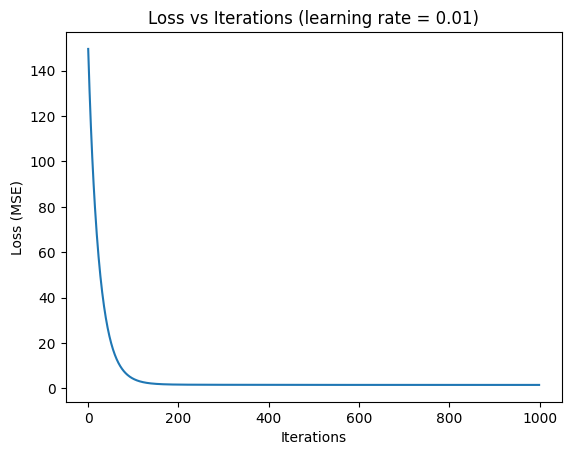

In [7]:
weights, loss_history = gradient_descent(X_train_scaled, y_train, learning_rate=0.01, iterations=1000)

plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Iterations (learning rate = 0.01)")
plt.show()

**Explanation:** Trains the model with a chosen learning rate (0.01) for 1000 iterations and plots how the loss decreases over time, showing convergence.

Task 7:Plot the loss (cost) versus the number of iterations.

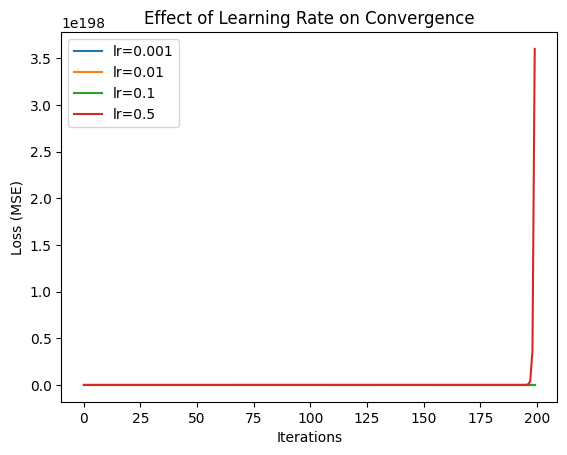

In [8]:
learning_rates = [0.001, 0.01, 0.1, 0.5]

plt.figure()
for lr in learning_rates:
    _, loss_hist = gradient_descent(X_train_scaled, y_train, learning_rate=lr, iterations=200)
    plt.plot(loss_hist, label=f"lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.show()

**Explanation:** Compares different learning rates to see their effect on convergence speed. Too small a learning rate converges slowly; too large may cause instability or divergence.

Task 8:Evaluate the trained model using:
Mean Absolute Error (MAE)
Mean Squared Error (MSE)
Root Mean Squared Error (RMSE)
R² Score


In [9]:
X_test_b = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])
y_pred_test = X_test_b @ weights

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R2 Score:", round(r2, 4))

MAE : 0.7683
MSE : 1.4905
RMSE: 1.2208
R2 Score: 0.8472


**Explanation:** Evaluates the trained model on the test set using MAE, MSE, RMSE, and R² Score — the standard regression performance metrics.

Task 9:Interpret the results and comment on the convergence behavior and prediction performance of the model.

### Interpretation
- The **loss vs iterations** plot shows the model converging as Gradient Descent minimizes the MSE loss.
- From the learning rate comparison: a **very small learning rate** converges slowly, a **moderate rate** (e.g. 0.01–0.1) converges smoothly, and a **very large rate** can cause the loss to oscillate or diverge.
- A low **RMSE**/**MAE** and an **R² Score** close to 1 indicate the model predicts final grades (`G3`) well; an R² closer to 0 indicates weak predictive power.
- Overall, Gradient Descent successfully optimizes the Linear Regression model, and its performance depends heavily on the chosen learning rate and number of iterations.